<a href="https://colab.research.google.com/github/ro9899/python-basics-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Spam Email Classification Using TensorFlow

## Problem Statement

Spam emails are unwanted messages that are often sent in large numbers and may contain advertisements, scams, or potentially harmful content. Identifying these emails manually can be difficult and time-consuming, especially when dealing with a large number of messages.

This project aims to develop an **AI-based spam email classification system** using **Python and TensorFlow**. The model analyzes the content of emails and classifies them into two categories: **Spam** or **Ham (Not Spam)**.

The objective is to create an automated system that can accurately detect unwanted emails and help improve email filtering and inbox security.


## Step 1: Import Required Libraries

First, we import all the libraries needed for the project. These libraries will help us with **data handling, text processing, model development, and visualization**.

We use **Pandas and NumPy** for working with the dataset, **TensorFlow** for building the spam classification model, **Matplotlib and WordCloud** for visualization, and **NLTK** for processing and cleaning the email text.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Step 2: Load the Dataset

Next, we load the email dataset that will be used to train and evaluate our model. The dataset contains email messages along with their labels, where each message is classified as either **Spam** or **Ham (Not Spam)**.

After loading the dataset, we inspect its structure, check the available columns, and understand the type of data we will be working with before moving on to data preprocessing.


In [3]:
data = pd.read_csv('/spam_ham_dataset (1).csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


This will give us a glimpse into the first few rows of the dataset. You can also check the shape of the dataset:

In [4]:
data.shape

(5171, 4)

The dataset contains **5,171 email records** and **4 columns**. Before training the model, we first check how the emails are distributed between the **Spam** and **Ham** categories.

Visualizing the label distribution helps us understand whether the dataset is balanced or if one class has significantly more samples than the other.


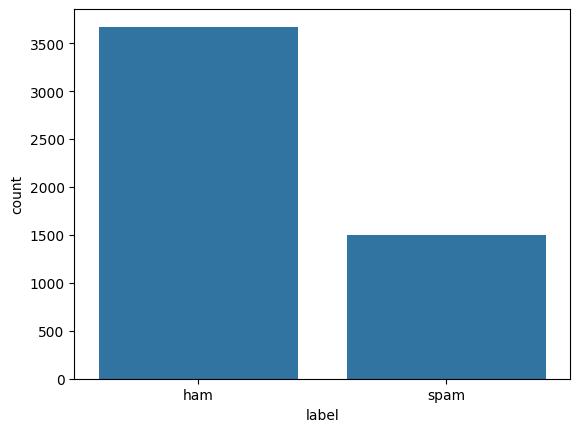

In [5]:
sns.countplot(x='label', data=data)
plt.show()

## Step 3: Balance the Dataset

After checking the class distribution, we can see that the number of **Ham emails is much higher than Spam emails**. This makes the dataset imbalanced, which can affect the model's performance.

To solve this issue, we reduce the number of Ham samples so that both **Spam and Ham classes have an equal number of samples**. This helps the model learn both categories more fairly and reduces the chances of bias toward the majority class.


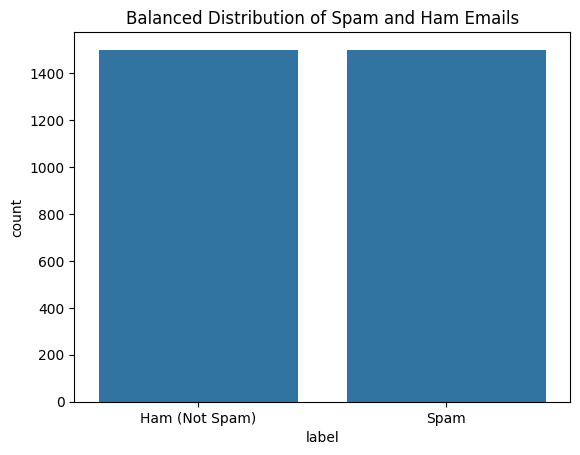

In [6]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

## Step 4: Clean the Text

Before using email messages for model training, we need to clean and prepare the text data. Raw email text can contain unnecessary words, punctuation, and different forms of the same word, which can make the data harder for the model to process.

In this step, we will perform the following text preprocessing tasks:

* **Remove Stopwords** – Remove common words that usually do not add much meaning to the classification task.
* **Remove Punctuation** – Remove unnecessary punctuation marks from the email text.
* **Stemming or Lemmatization** – Convert words into their root or base form to reduce variations of the same word.

This preprocessing helps reduce unnecessary noise and converts the raw email content into a cleaner format that can be used effectively for machine learning.


In [7]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [8]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text']= balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


The following helper function is used to remove common **stopwords** from the email text. Removing these words helps reduce unnecessary information and makes the text cleaner for further processing.


In [9]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


Visualization: Word Cloud

A word cloud is a visual way to represent the words that appear most frequently in a collection of text. In this project, it helps us quickly identify the most commonly used words in the email dataset and understand the overall content of the messages.

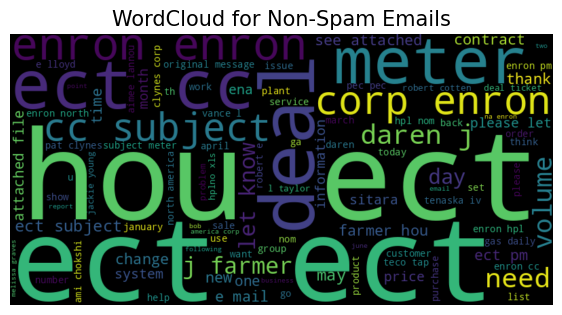

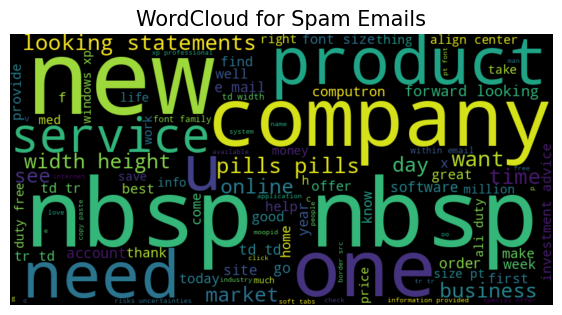

In [10]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

## Step 6: Tokenization and Padding

Since machine learning models cannot directly process raw text, we need to convert the email messages into a numerical format before training the model.

* **Tokenization:** Converts words in the email text into numerical values (tokens) so that the model can process them.
* **Padding:** Makes all tokenized sequences the same length by adding extra values where necessary.

This step converts the cleaned email text into a consistent numerical format that can be provided as input to the deep learning model.


In [12]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

## Step 7: Define the Model

For this project, we build a **deep learning model using TensorFlow's Sequential architecture**. The model processes the tokenized email text and learns patterns that help distinguish between Spam and Ham emails.

The model consists of the following layers:

* **Embedding Layer:** Converts the tokenized words into meaningful numerical representations.
* **LSTM Layer:** Learns important patterns and relationships between words in the email sequence.
* **Fully Connected Layer:** Uses the learned information to extract useful features for classification.
* **Output Layer:** Produces the final prediction, identifying the email as **Spam or Ham**.

This architecture allows the model to learn from the sequence of words and make an automated classification.


In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=32
    ),

    tf.keras.layers.LSTM(16),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │     1,274,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the Model

After defining the model architecture, we train it using the prepared email dataset. During training, we use **EarlyStopping** and **ReduceLROnPlateau** callbacks to improve the training process.

* **EarlyStopping:** Stops training when the model stops showing improvement, which helps prevent unnecessary training and overfitting.
* **ReduceLROnPlateau:** Automatically lowers the learning rate when the model's performance stops improving, allowing the model to fine-tune its learning.

These techniques help the model train more efficiently and achieve better performance on unseen email data.


In [17]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5634 - loss: 0.6828 - val_accuracy: 0.6433 - val_loss: 0.6146 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6793 - loss: 0.5652 - val_accuracy: 0.6467 - val_loss: 0.5693 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6960 - loss: 0.5147 - val_accuracy: 0.6833 - val_loss: 0.5145 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9208 - loss: 0.2438 - val_accuracy: 0.9317 - val_loss: 0.2343 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9629 - loss: 0.1395 - val_accuracy: 0.9517 - val_loss: 0.1869 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9758 - loss: 0.1067 - val_accuracy: 0.9550 - val_loss: 0.1813 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9804 - loss: 0.0871 - val_acc

After completing the training process, we evaluate the model using the test dataset to check how well it performs on unseen email messages. This helps us measure the model’s ability to correctly classify emails as Spam or Ham.

In [18]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9650 - loss: 0.1663
Test Loss : 0.16627992689609528
Test Accuracy : 0.9649999737739563




### Model Performance

The model was evaluated on the test dataset and achieved a **test accuracy of 96.50%**, with a **test loss of 0.1663**.

This means the model correctly classified approximately **96.5% of the unseen email samples** as Spam or Ham. The low test loss also indicates that the model is making predictions with good overall performance.

**Results:**

* **Test Accuracy:** 96.50%
* **Test Loss:** 0.1663
* **Evaluation Steps:** 19/19

Overall, the results show that the trained LSTM-based model performs well in detecting spam emails.


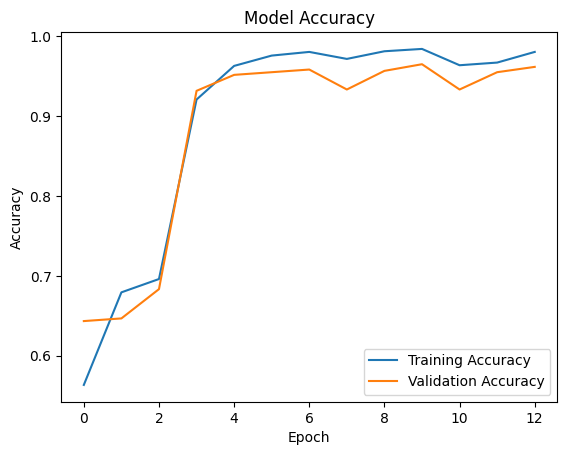

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

**### Conclusion**

By completing these steps, we successfully developed a **deep learning model using TensorFlow** to classify emails as **Spam or Ham**. The model achieved a **test accuracy of 96.50%**, showing that it can effectively identify unwanted emails.

With further improvements in **data preprocessing, model architecture, hyperparameter tuning, and training techniques**, the model's performance could potentially be improved further.
